In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install flowio

In [3]:
import pandas as pd
import pickle
import os
import numpy as np
import sys

In [4]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [5]:
decache_files = ['utils', 'timepoints_elaboration', 'cv_folds', 'show_results', 'classification']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from timepoints_elaboration import load_data, donation_extraction

from show_results import retrieve_samples_info, show_patients_samples_info
from show_results import show_dotbox_heat, show_ensemble_heatmap, show_dotbox_dotbox, show_all_LOPO_boxplots
from show_results import retrieve_all_LOPO_thresholds, elaborate_data_for_box_violin
from show_results import retrieve_blast_perc, cumulative_num_samples_sum


from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds
from utils import flatten, show_blast_distribution_perc, retireve_sorted_pat_sample_ids, retrieve_labels
from classification import compute_metrics, compute_mean_std_metrics
from classification import seed_level_robust_prediction_labelling

utils removed from cache
timepoints_elaboration not found in cache
cv_folds not found in cache
show_results not found in cache
classification not found in cache


In [6]:

data_folder_dir = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder_dir, ext = extension)#, remove_control = True)


0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

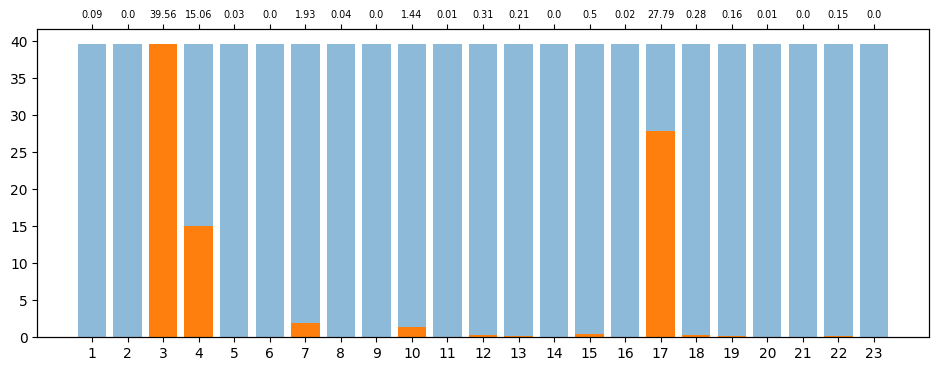

In [7]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS,multiple_donations, return_perc = True)


/content/drive/MyDrive/0.Master_Thesis/CellCNN/modules/show_results.py:732: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


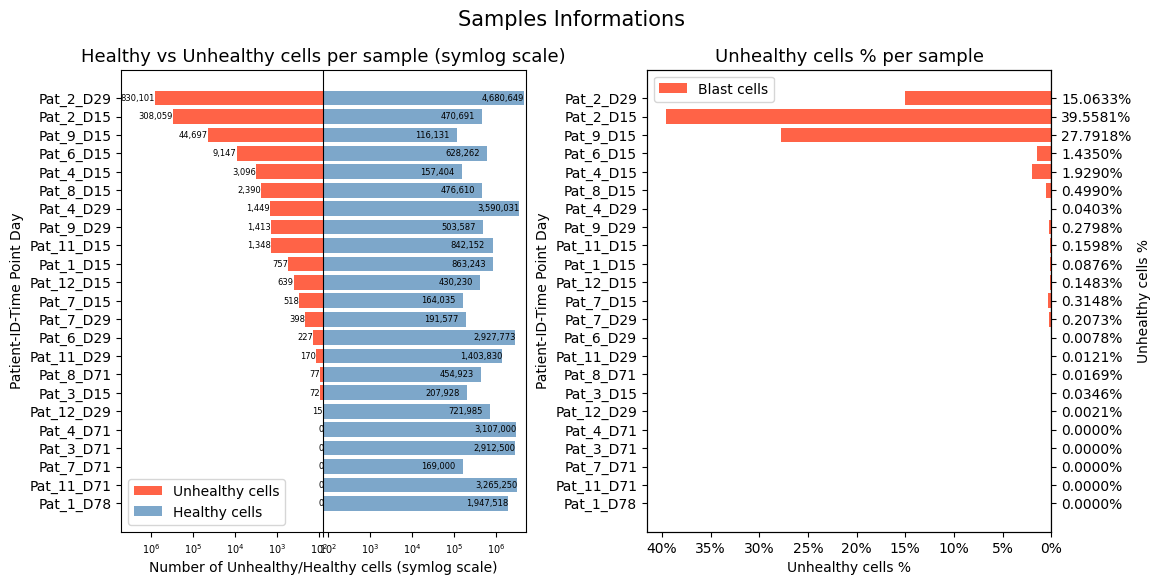

In [8]:

samples_info_dict = retrieve_samples_info(data_folder_dir, multiple_donations, ALL_DATASETS)
show_patients_samples_info(samples_info_dict, numbers = True)

In [9]:

tuning_exp = 'Trial_4_NO_AS_bayesian_tuning'

config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)
starting_seed = config['starting_seed']

plot_exp = '4_plots'
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)


In [10]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

# Training Procedure 1

In [27]:
exp = 'Trial_4_AS_single_split'

exp = 'Trial_4_NO_AS_single_split'

if 'NO_AS' in exp:
    exp_plot_name = 'NO_AS'
else:
    exp_plot_name = 'AS'

sub_figsize = (4,5)

In [28]:
save_lopo_ens_dir = f'{cellcnn_path}/experiments/experiment_{exp}/'
LOPO_folds = len([fold_name for fold_name in list(os.listdir(save_lopo_ens_dir)) if 'fold' in fold_name])
print(LOPO_folds)


left_out_pat_list = []
for LOPO_idx, _ in enumerate(range(LOPO_folds)):
    save_ensemble_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/ensemble/results/'

    test_pat = LOPOCV_patients_folds[LOPO_idx][1]
    left_out_pat_list.append(test_pat)
left_out_pat_list = flatten(left_out_pat_list)
print(left_out_pat_list)


10
['1', '2', '3', '4', '6', '7', '8', '9', '11', '12']


In [29]:

save_single_split_dir = f'{cellcnn_path}/experiments/experiment_{exp}/'
LOPO_folds = len([fold_name for fold_name in list(os.listdir(save_single_split_dir)) if 'fold' in fold_name])
print(LOPO_folds)

print('Direct prediction data elaboration started!')
all_dir_metrics = [] # stores single cellcnn seetings metrics grouped by LOPO iterations
all_dir_metrics_across_LOPO_single = []  # stores single cellcnn seetings metrics across all LOPO iterations
all_dir_single_metrics = [] # stores ensemble metrics

for i, _ in enumerate(range(LOPO_folds)):

    # === Import LOPOCV iteration-specific results === #
    save_original_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{i}/results/direct'

    with open(os.path.join(save_original_dir, 'original_predictions_list.pkl'), 'rb') as f:
                    original_predictions_list = pickle.load(f)

    with open(os.path.join(save_original_dir, 'original_results_list.pkl'), 'rb') as f:
                        original_results_list = pickle.load(f)

    with open(os.path.join(save_original_dir, 'original_test_y.pkl'), 'rb') as f:
                         original_test_y = pickle.load(f)

    # extract samples probability of belonging in the unhealthy class
    pred_per_seed = []
    for pat in original_predictions_list:
        pos_pred_sample = [sample[1] for sample in pat]  # probability of belonging in the unhealthy class
        pred_per_seed.append(pos_pred_sample)
        seed_metrics = compute_metrics(original_test_y, pos_pred_sample, 0.5) # dict of performance metrics
        all_dir_metrics_across_LOPO_single.append(seed_metrics) # store each patient

    # compute preditions for the weigths-ensemble
    df = pd.DataFrame(pred_per_seed)
    mean_preds_across_seeds = df.mean(axis = 0).to_numpy() # average across weights initializations
    mean_preds_metrics = compute_metrics(original_test_y, mean_preds_across_seeds, 0.5)
    all_dir_single_metrics.append(mean_preds_metrics)

    # compute metrics per weight initialization
    metrics_across_seeds = []
    for w_init in df.index:
        metrics_across_seeds.append(compute_metrics(original_test_y, df.iloc[w_init], 0.5))

    met_df = pd.DataFrame(metrics_across_seeds)

    direct_metrics_across_trials = {}
    for met in met_df.columns:
        direct_metrics_across_trials[met] = met_df[met].to_list()

    all_dir_metrics.append(direct_metrics_across_trials)

print('Direct prediction data elaboration ended!')
print('Direct prediction plotting started!')



10
Direct prediction data elaboration started!
Direct prediction data elaboration ended!
Direct prediction plotting started!


In [30]:

save_direct_plot_dir = f'{thesis_images_dir}/{exp_plot_name}_single/dir/'
os.makedirs(save_direct_plot_dir, exist_ok=True)

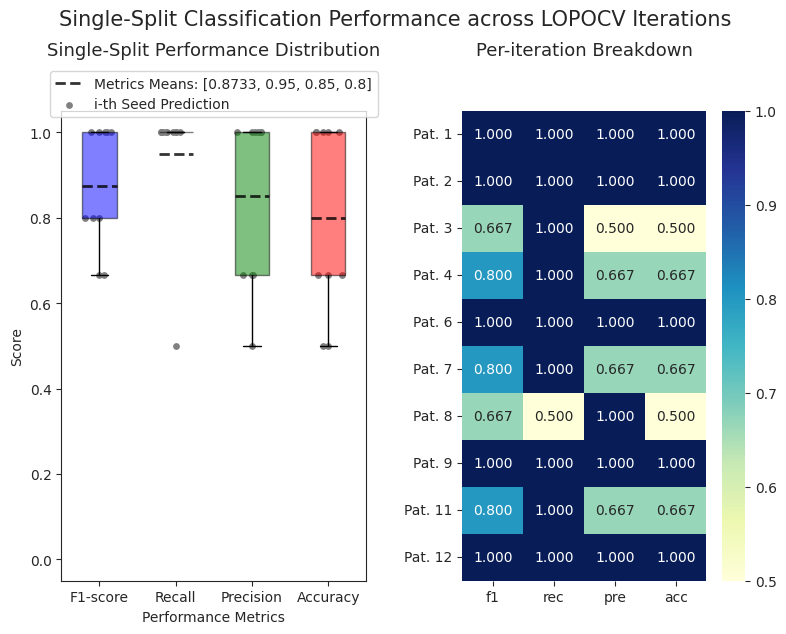

In [31]:
show_dotbox_heat(all_dir_single_metrics,
                 dots = True,
                 title_1 = 'Single-Split Performance Distribution',
                 title_2 = 'Per-iteration Breakdown',
                 sup_title = 'Single-Split Classification Performance across LOPOCV Iterations',
                 file_name = f'single_perf_distr_{exp_plot_name}_dir',
                 save_dir = save_direct_plot_dir,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1, fold_or_seed = 'Seed')

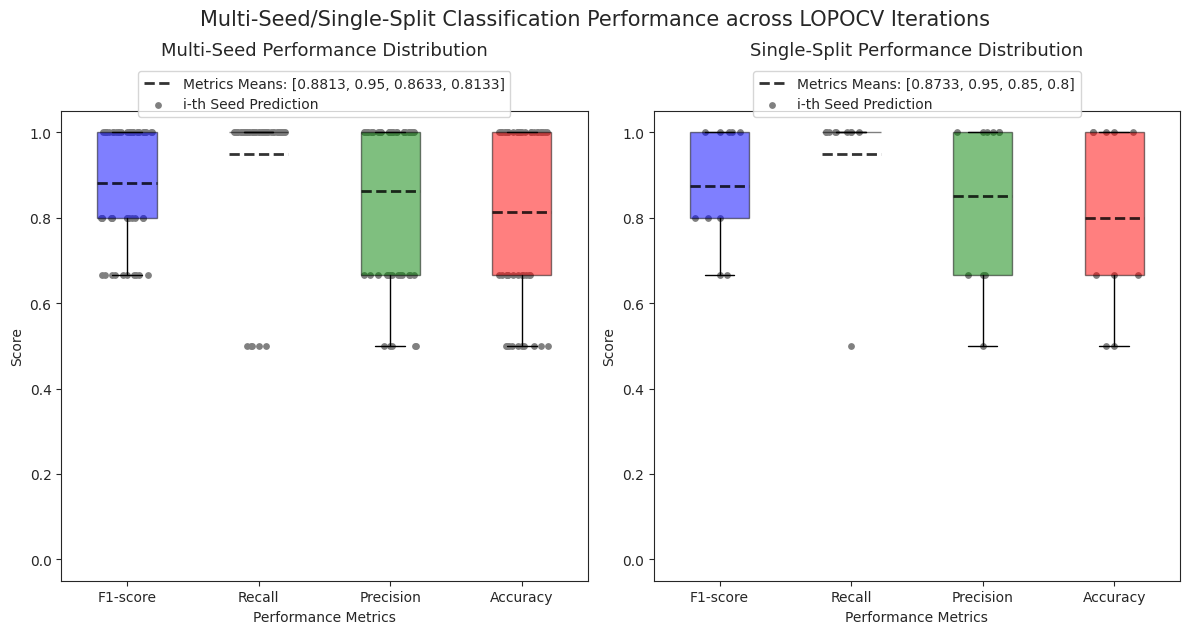

In [32]:
show_dotbox_dotbox(all_dir_single_metrics, all_dir_metrics_across_LOPO_single,
                 dots = True,
                 title_1 = 'Multi-Seed Performance Distribution',
                 title_2 = 'Single-Split Performance Distribution',

                 sup_title = 'Multi-Seed/Single-Split Classification Performance across LOPOCV Iterations',
                 file_name = f'multi_single_perf_distr_{exp_plot_name}_dir',
                 save_dir = save_direct_plot_dir,
                 sub_figsize = (6,5),
                 legend_pos = 1.1, fold_or_seed = 'Seed')

# Single Split ROC

In [33]:
# === Retrieve ROC and RES tuned thresholds === #
roc_thr_per_fold, res_thr_per_fold = retrieve_all_LOPO_thresholds(LOPO_folds, cellcnn_path, tuning_exp)
print(roc_thr_per_fold)
print(res_thr_per_fold)

# === Elaborate Resampling Approaches === #

all_roc_metrics_across_LOPO_single = []
all_res_metrics_across_LOPO_single = []

all_roc_single_metrics = []
all_res_single_metrics = []

all_roc_metrics = []
all_rob_metrics = []
for i, _ in enumerate(range(LOPO_folds)):

    # retrieve iteration-specific thresholds
    roc_TUNED_THRESHOLD = roc_thr_per_fold[i]
    res_TUNED_THRESHOLD = res_thr_per_fold[i]

    # retrieve predictions
    save_robust_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{i}/results/robust/roc/'

    with open(os.path.join(save_robust_dir, 'test_total_trial_pred_lists.pkl'), 'rb') as f:
                        test_total_trial_pred_lists = pickle.load(f)

    with open(os.path.join(save_robust_dir, 'per_donor_original_test_y.pkl'), 'rb') as f:
                        per_donor_original_test_y = pickle.load(f)

    # flatten ground truth labels
    per_donor_original_test_y_flat = flatten(per_donor_original_test_y)
    print(f'Timepoints Labels: {per_donor_original_test_y}')

    # === compute performance metrics at seed level classifying with \tau^*_ROC  or \tau^*RES=== #
    all_preds_across_LOPO = []
    _, patient_timepoints_preds = seed_level_robust_prediction_labelling(test_total_trial_pred_lists, roc_TUNED_THRESHOLD*100, pred = True)
    df = pd.DataFrame(patient_timepoints_preds[0]).T
    for seed_idx in df.index:
        seed_preds = df.iloc[seed_idx].to_numpy()
        all_preds_across_LOPO.append(seed_preds)

        roc_seed_metrics = compute_metrics(per_donor_original_test_y_flat, seed_preds, roc_TUNED_THRESHOLD)
        all_roc_metrics_across_LOPO_single.append(roc_seed_metrics)

        res_seed_metrics = compute_metrics(per_donor_original_test_y_flat, seed_preds, res_TUNED_THRESHOLD)
        all_res_metrics_across_LOPO_single.append(res_seed_metrics)

    # === compute performance metrics of the seed-Ensemble classifying with \tau^*_ROC or \tau^*_RES === #

    df = pd.DataFrame(all_preds_across_LOPO)
    mean_df = df.mean(axis = 0).to_numpy()

    roc_mean_preds_metrics = compute_metrics(per_donor_original_test_y_flat, mean_df,  roc_TUNED_THRESHOLD)
    all_roc_single_metrics.append(roc_mean_preds_metrics)

    res_mean_preds_metrics = compute_metrics(per_donor_original_test_y_flat, mean_df,  res_TUNED_THRESHOLD)
    all_res_single_metrics.append(res_mean_preds_metrics)




[np.float64(0.5809186100959778), np.float64(0.6494543353716532), np.float64(0.7449084520339966), np.float64(0.6443087458610535), np.float64(0.6817862788836161), np.float64(0.6728426814079285), np.float64(0.7872222264607748), np.float64(0.6363522609074911), np.float64(0.6741575201352438), np.float64(0.6408588886260986)]
[np.float64(0.5), np.float64(0.5), np.float64(0.74), np.float64(0.65), np.float64(0.5), np.float64(0.73), np.float64(0.77), np.float64(0.61), np.float64(0.66), np.float64(0.5)]
Timepoints Labels: [[1, 0]]
Timepoints Labels: [[1, 1]]
Timepoints Labels: [[1, 0]]
Timepoints Labels: [[1, 1, 0]]
Timepoints Labels: [[1, 1]]
Timepoints Labels: [[1, 1, 0]]
Timepoints Labels: [[1, 1]]
Timepoints Labels: [[1, 1]]
Timepoints Labels: [[1, 1, 0]]
Timepoints Labels: [[1, 1]]


In [34]:
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)


save_direct_plot_ROC = f'{thesis_images_dir}/{exp_plot_name}_single/ROC/'
os.makedirs(save_direct_plot_ROC, exist_ok=True)

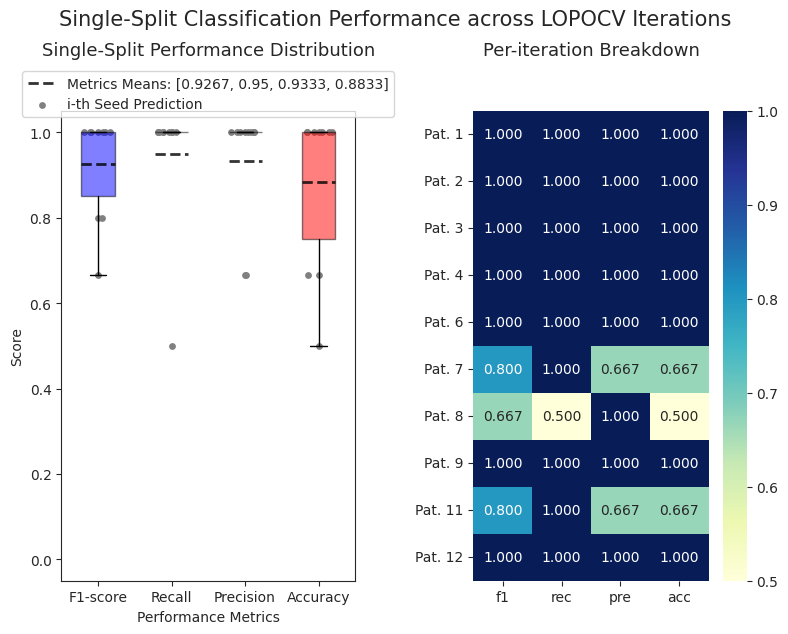

In [35]:
show_dotbox_heat(all_roc_single_metrics,
                 dots = True,
                 title_1 = 'Single-Split Performance Distribution',
                 title_2 = 'Per-iteration Breakdown',
                 sup_title = 'Single-Split Classification Performance across LOPOCV Iterations',
                 file_name = f'single_perf_distr_{exp_plot_name}_dir',
                 save_dir = save_direct_plot_dir,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1, fold_or_seed = 'Seed')

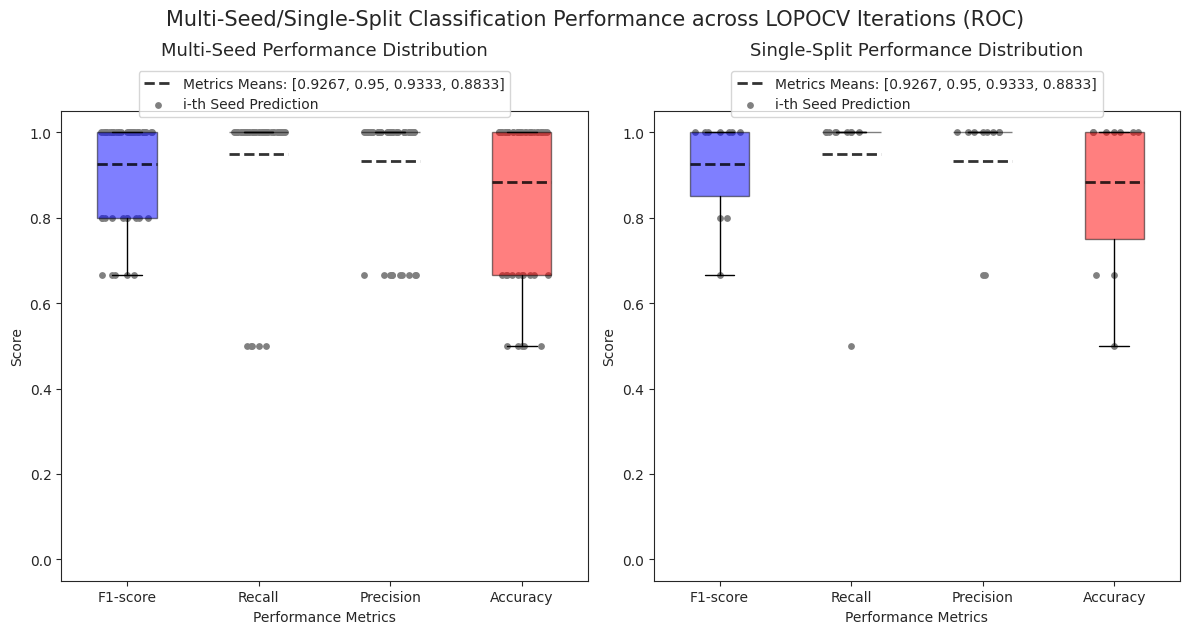

In [36]:
show_dotbox_dotbox(all_roc_single_metrics, all_roc_metrics_across_LOPO_single,
                 dots = True,
                 title_1 = 'Multi-Seed Performance Distribution',
                 title_2 = 'Single-Split Performance Distribution',

                 sup_title = 'Multi-Seed/Single-Split Classification Performance across LOPOCV Iterations (ROC)',
                 file_name = f'multi_single_perf_distr_{exp_plot_name}_ROC',
                 save_dir = save_direct_plot_ROC,
                 sub_figsize = (6,5),
                 legend_pos = 1.1, fold_or_seed = 'Seed')

# Single Split RES

In [37]:
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)


save_direct_plot_RES = f'{thesis_images_dir}/{exp_plot_name}_single/RES/'
os.makedirs(save_direct_plot_RES, exist_ok=True)

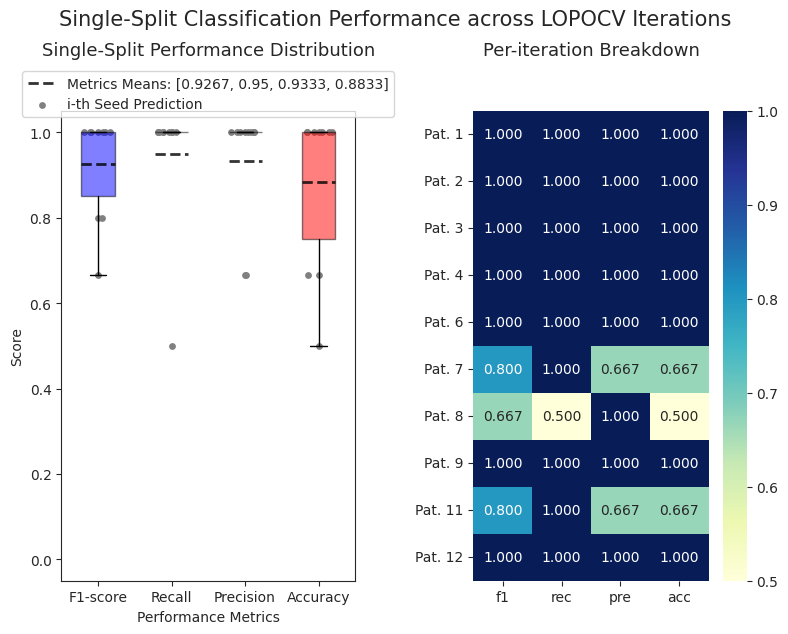

In [38]:
show_dotbox_heat(all_res_single_metrics,
                 dots = True,
                 title_1 = 'Single-Split Performance Distribution',
                 title_2 = 'Per-iteration Breakdown',
                 sup_title = 'Single-Split Classification Performance across LOPOCV Iterations',
                 file_name = f'single_perf_distr_{exp_plot_name}_dir',
                 save_dir = save_direct_plot_dir,
                 left_out_pat_list = left_out_pat_list,
                 sub_figsize = sub_figsize,
                 legend_pos = 1.1, fold_or_seed = 'Seed')

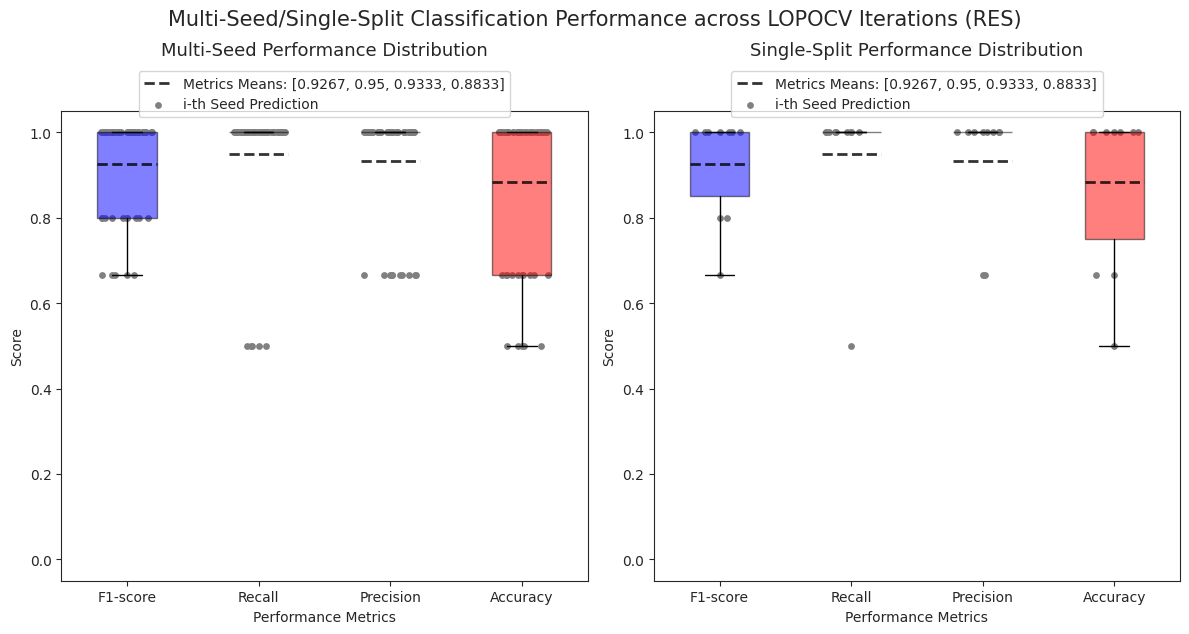

In [39]:
show_dotbox_dotbox(all_res_single_metrics, all_res_metrics_across_LOPO_single,
                 dots = True,
                 title_1 = 'Multi-Seed Performance Distribution',
                 title_2 = 'Single-Split Performance Distribution',

                 sup_title = 'Multi-Seed/Single-Split Classification Performance across LOPOCV Iterations (RES)',
                 file_name = f'multi_single_perf_distr_{exp_plot_name}_RES',
                 save_dir = save_direct_plot_RES,
                 sub_figsize = (6,5),
                 legend_pos = 1.1, fold_or_seed = 'Seed')

# Compute performance metrics Mean and Std across LOPO iterations

In [40]:
tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/DIR/'
os.makedirs(tables_dir, exist_ok=True)

# CellCNN approach

all_lopo_mean_std_dict = compute_mean_std_metrics(all_dir_metrics_across_LOPO_single, 4)
across_lopo_mean_std_dict = compute_mean_std_metrics(all_dir_single_metrics, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict , f)


print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)
print('')

# Resampling approach with \tau_ROC

tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/ROC/'
os.makedirs(tables_dir, exist_ok=True)

all_lopo_mean_std_dict = compute_mean_std_metrics(all_roc_metrics_across_LOPO_single, 4)
across_lopo_mean_std_dict = compute_mean_std_metrics(all_roc_single_metrics, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict , f)

print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)
print('')

# Resampling approach with \tau_RES

tables_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/RES/'
os.makedirs(tables_dir, exist_ok=True)

all_lopo_mean_std_dict = compute_mean_std_metrics(all_res_metrics_across_LOPO_single, 4)
across_lopo_mean_std_dict = compute_mean_std_metrics(all_res_single_metrics, 4)

with open(os.path.join(tables_dir, 'all_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(all_lopo_mean_std_dict , f)
with open(os.path.join(tables_dir, 'across_lopo_mean_std_dict.pkl'), 'wb') as f:
        pickle.dump(across_lopo_mean_std_dict , f)

print(all_lopo_mean_std_dict)
print(across_lopo_mean_std_dict)

{'f1': [np.float64(0.8813), np.float64(0.1375)], 'rec': [np.float64(0.95), np.float64(0.1515)], 'pre': [np.float64(0.8633), np.float64(0.1896)], 'acc': [np.float64(0.8133), np.float64(0.212)]}
{'f1': [np.float64(0.8733), np.float64(0.1421)], 'rec': [np.float64(0.95), np.float64(0.1581)], 'pre': [np.float64(0.85), np.float64(0.1995)], 'acc': [np.float64(0.8), np.float64(0.2194)]}

{'f1': [np.float64(0.9267), np.float64(0.1184)], 'rec': [np.float64(0.95), np.float64(0.1515)], 'pre': [np.float64(0.9333), np.float64(0.1347)], 'acc': [np.float64(0.8833), np.float64(0.1852)]}
{'f1': [np.float64(0.9267), np.float64(0.1235)], 'rec': [np.float64(0.95), np.float64(0.1581)], 'pre': [np.float64(0.9333), np.float64(0.1405)], 'acc': [np.float64(0.8833), np.float64(0.1933)]}

{'f1': [np.float64(0.9267), np.float64(0.1184)], 'rec': [np.float64(0.95), np.float64(0.1515)], 'pre': [np.float64(0.9333), np.float64(0.1347)], 'acc': [np.float64(0.8833), np.float64(0.1852)]}
{'f1': [np.float64(0.9267), np.flo

# Positive score boxplots across LOPOCV iterations

In [41]:
# === Retrieve ROC and RES tuned thresholds === #
roc_thr_per_fold, res_thr_per_fold = retrieve_all_LOPO_thresholds(LOPO_folds, cellcnn_path, tuning_exp)
print(roc_thr_per_fold)
print(res_thr_per_fold)


[np.float64(0.5809186100959778), np.float64(0.6494543353716532), np.float64(0.7449084520339966), np.float64(0.6443087458610535), np.float64(0.6817862788836161), np.float64(0.6728426814079285), np.float64(0.7872222264607748), np.float64(0.6363522609074911), np.float64(0.6741575201352438), np.float64(0.6408588886260986)]
[np.float64(0.5), np.float64(0.5), np.float64(0.74), np.float64(0.65), np.float64(0.5), np.float64(0.73), np.float64(0.77), np.float64(0.61), np.float64(0.66), np.float64(0.5)]


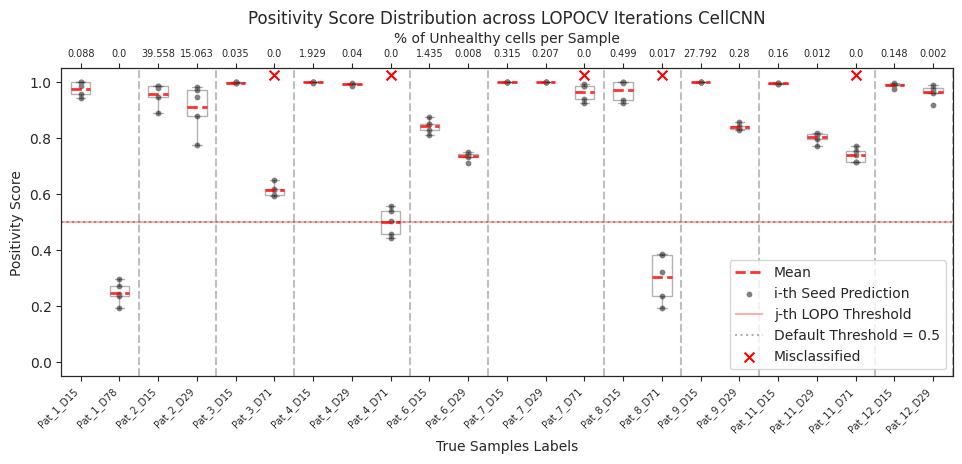

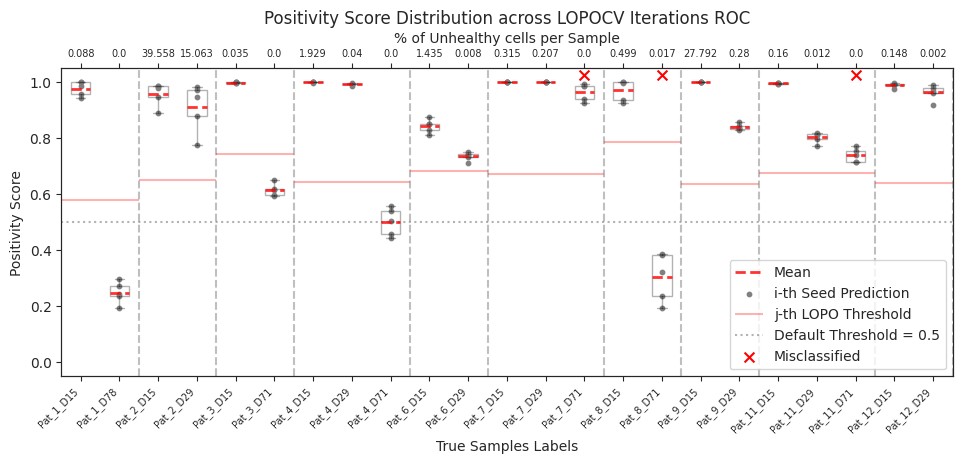

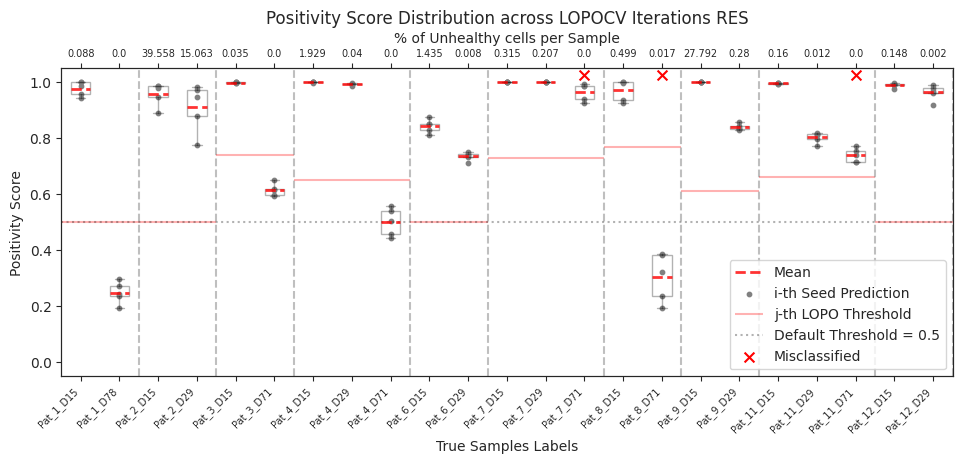

In [42]:

per_LOPO_blast_perc = []
per_LOPO_boxplot_data = []

for LOPO_idx, _ in enumerate(range(LOPO_folds)):

    test_pat = LOPOCV_patients_folds[LOPO_idx][1] # retrieve patient ID

    # extract samples from test patient
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    per_donor_original_test_datasets, per_donor_original_test_y = retrieve_labels(test_datasets_extracted, remove = False)

    # compute exact percentage of unhealthy cells in each sample
    patient_blast_perc = retrieve_blast_perc(per_donor_original_test_datasets)
    per_LOPO_blast_perc.append(patient_blast_perc)


    num_samples = len(flatten(per_donor_original_test_y))
    save_robust_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPO_idx}/results/robust/roc/'

    # compute and store Positivity scores in the right format
    plot_data, boxplot_data = elaborate_data_for_box_violin(save_robust_dir)
    per_LOPO_boxplot_data.append(boxplot_data)

# === Show Ensemble Boxplot === #

pat_sample_ids = retireve_sorted_pat_sample_ids(samples_info_dict)
default_thr_list = [0.5 for i in range(len(roc_thr_per_fold))]

thr_list_coll = [default_thr_list, roc_thr_per_fold, res_thr_per_fold] # thr lists

type_thr = ['CellCNN', 'ROC', 'RES']

for thr_list, type_pred in zip(thr_list_coll, type_thr):
    save_direct_plot = f'{thesis_images_dir}/{exp_plot_name}_single/{type_pred}/'
    os.makedirs(save_direct_plot, exist_ok=True)

    num_samples_cum = cumulative_num_samples_sum(per_LOPO_boxplot_data)
    per_LOPO_boxplot_data_flat = flatten(per_LOPO_boxplot_data)
    per_LOPO_blast_perc_flat = flatten(per_LOPO_blast_perc)

    # show boxplot
    show_all_LOPO_boxplots(per_LOPO_boxplot_data_flat, per_LOPO_blast_perc_flat, thr_list,
                           num_samples_cum,
                           save_dir = save_direct_plot,
                           file_name = f'samples_boxplots_per_lopocv_single_{type_pred}.pdf',
                           title = f'Positivity Score Distribution across LOPOCV Iterations {type_pred}',
                           fold_or_seed = 'Seed',
                           y_labels = pat_sample_ids[:num_samples_cum[LOPO_folds-1]])

# === save images === #
pos_score_dir = f'{thesis_images_dir}/mean_std_tables_{exp}/'
os.makedirs(pos_score_dir, exist_ok=True)

with open(os.path.join(pos_score_dir, 'thr_list_coll.pkl'), 'wb') as f:
        pickle.dump(thr_list_coll , f)
with open(os.path.join(pos_score_dir, 'per_LOPO_boxplot_data.pkl'), 'wb') as f:
        pickle.dump(per_LOPO_boxplot_data , f)
